In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Optional
import time

2026-02-13 12:50:48.944570: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 12:50:48.956453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771005048.968528  270830 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771005048.972490  270830 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771005048.981425  270830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [ ]:
# Check for GPU
gpu_devices = tf.config.list_physical_devices('GPU')

if gpu_devices:
    print(f"✅ GPU detected: {gpu_devices}")
    # This specifically checks if it's usable
    print(f"Device Name: {tf.test.gpu_device_name()}")
else:
    print("❌ No GPU found. TensorFlow is running on CPU.")

# Simple math test to ensure TF is working
print(f"TF Version: {tf.__version__}")
print(f"Addition test: {tf.add(1, 2).numpy()}")

✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Device Name: /device:GPU:0
TF Version: 2.19.1
Addition test: 3


I0000 00:00:1771005272.294685  270830 gpu_device.cc:2019] Created device /device:GPU:0 with 7718 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:65:00.0, compute capability: 8.6
I0000 00:00:1771005272.296510  270830 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7718 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:65:00.0, compute capability: 8.6


Configuration

In [ ]:
CSV_PATH = './gazebo_dataset_01272026/labels_01272026.csv'
IMG_DIR = './gazebo_dataset_01272026/images/'
EDGE_DIR = './gazebo_dataset_01272026/edge_detection_results_01272026/'

# Hyperparameters
NUM_ROUNDS = 25
NUM_CLIENTS = 2
LOCAL_EPOCHS = 1
K_FOLDS = 10
HED_FREEZE_ROUND = 16
RGB_FREEZE_ROUND = 20
IMG_SIZE = 128
BATCH_SIZE = 16

# Memory optimization: validation batch size for inference
VAL_BATCH_SIZE = 32

Data Loading (Optimized)

In [ ]:
image_cache = {}

def load_image_cached(img_path: str) -> np.ndarray:
    """Load and cache images to avoid redundant disk I/O."""
    if img_path not in image_cache:
        img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
        img = img_to_array(img) / 255.0
        image_cache[img_path] = img
    return image_cache[img_path]


def create_dataset_optimized(
    dataframe: pd.DataFrame,
    image_dir: str,
    load_images: bool = True
) -> Tuple:
    """
    Optimized dataset creation that can return either:
    1. Full numpy arrays (for training - smaller datasets)
    2. File paths only (for validation - larger datasets, used with generators)

    Args:
        dataframe: DataFrame with image paths and labels
        image_dir: Directory containing images
        load_images: If True, load all images into memory. If False, return paths only.
    """
    suffix = '_hed' if image_dir == EDGE_DIR else ''

    if load_images:
        # Load everything into memory (for training data - typically smaller per client)
        current_images = []
        dest_images = []
        labels = []

        for idx, row in dataframe.iterrows():
            current_img = load_image_cached(image_dir + row['current_image'][:-4] + suffix + '.png')
            dest_img = load_image_cached(image_dir + row['destination_image'][:-4] + suffix + '.png')

            current_images.append(current_img)
            dest_images.append(dest_img)
            labels.append(row['direction_label'])

        return np.array(current_images), np.array(dest_images), np.array(labels)
    else:
        # Return paths only (for validation - use with data generator)
        current_paths = []
        dest_paths = []
        labels = []

        for idx, row in dataframe.iterrows():
            current_paths.append(image_dir + row['current_image'][:-4] + suffix + '.png')
            dest_paths.append(image_dir + row['destination_image'][:-4] + suffix + '.png')
            labels.append(row['direction_label'])

        return current_paths, dest_paths, np.array(labels)

In [ ]:
class ValidationDataGenerator(tf.keras.utils.Sequence):
    """
    OPTIMIZATION 1: Memory-efficient validation data generator.

    Instead of loading all validation images at once, this loads them in batches
    during evaluation. Reduces memory footprint significantly.
    """
    def __init__(
        self,
        current_rgb_paths: List[str],
        current_hed_paths: List[str],
        dest_rgb_paths: List[str],
        dest_hed_paths: List[str],
        labels: np.ndarray,
        batch_size: int = VAL_BATCH_SIZE
    ):
        self.current_rgb_paths = current_rgb_paths
        self.current_hed_paths = current_hed_paths
        self.dest_rgb_paths = dest_rgb_paths
        self.dest_hed_paths = dest_hed_paths
        self.labels = labels
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))

    def __getitem__(self, idx):
        batch_start = idx * self.batch_size
        batch_end = min((idx + 1) * self.batch_size, len(self.labels))

        # Load batch of images
        current_rgb = np.array([
            load_image_cached(self.current_rgb_paths[i])
            for i in range(batch_start, batch_end)
        ])
        current_hed = np.array([
            load_image_cached(self.current_hed_paths[i])
            for i in range(batch_start, batch_end)
        ])
        dest_rgb = np.array([
            load_image_cached(self.dest_rgb_paths[i])
            for i in range(batch_start, batch_end)
        ])
        dest_hed = np.array([
            load_image_cached(self.dest_hed_paths[i])
            for i in range(batch_start, batch_end)
        ])

        batch_labels = self.labels[batch_start:batch_end]

        return (current_rgb, current_hed, dest_rgb, dest_hed), batch_labels

MODEL ARCHITECTURE

In [ ]:
def rgb_encoder(input_shape):
    """RGB image encoder."""
    from tensorflow.keras import layers, models, Input

    inp = Input(shape=input_shape)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(96, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    return models.Model(inp, x, name="RGB_Encoder")


def hed_encoder(input_shape):
    """HED edge detection encoder."""
    from tensorflow.keras import layers, models, Input

    inp = Input(shape=input_shape)
    x = layers.Conv2D(16, 3, activation='relu', padding='same')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
    x = layers.LayerNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    return models.Model(inp, x, name="HED_Encoder")


def build_siamese_model(H: int = IMG_SIZE, W: int = IMG_SIZE):
    """Build the Siamese network model."""
    from tensorflow.keras import layers, models, Input

    # Inputs
    current_rgb = Input(shape=(H, W, 3))
    current_hed = Input(shape=(H, W, 3))
    dest_rgb = Input(shape=(H, W, 3))
    dest_hed = Input(shape=(H, W, 3))

    rgb_enc = rgb_encoder((H, W, 3))
    hed_enc = hed_encoder((H, W, 3))

    curr_feat = layers.Concatenate()([
        rgb_enc(current_rgb),
        hed_enc(current_hed)
    ])

    dest_feat = layers.Concatenate()([
        rgb_enc(dest_rgb),
        hed_enc(dest_hed)
    ])

    diff = layers.Subtract()([dest_feat, curr_feat])
    abs_diff = layers.Lambda(lambda x: tf.abs(x))(diff)

    final_feat = layers.Concatenate()([
        curr_feat, dest_feat, diff, abs_diff
    ])

    x = layers.Dense(256, activation='relu')(final_feat)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    output = layers.Dense(4, activation='softmax')(x)

    model = models.Model(
        inputs=[current_rgb, current_hed, dest_rgb, dest_hed],
        outputs=output
    )

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Federated Learning

In [ ]:
def federated_average_optimized(models: List) -> List[np.ndarray]:
    """
    OPTIMIZATION 2: More efficient federated averaging.

    Instead of creating intermediate lists and using np.stack for each layer,
    we directly compute the mean, reducing memory allocations.
    """
    num_models = len(models)
    weights = [m.get_weights() for m in models]
    num_layers = len(weights[0])

    new_weights = []

    for layer_idx in range(num_layers):
        # Directly compute mean without intermediate stack
        layer_sum = weights[0][layer_idx].copy()
        for model_idx in range(1, num_models):
            layer_sum += weights[model_idx][layer_idx]
        new_weights.append(layer_sum / num_models)

    return new_weights


def freeze_encoder(model, encoder_name: str):
    """Freeze a specific encoder and recompile."""
    model.get_layer(encoder_name).trainable = False
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )


class ClientData:
    """
    OPTIMIZATION 3: Better dataset organization.

    Instead of creating datasets multiple times, we load once and store
    in a structured class. This also makes the code cleaner.
    """
    def __init__(
        self,
        X_current: np.ndarray,
        X_dest: np.ndarray,
        X_current_hed: np.ndarray,
        X_dest_hed: np.ndarray,
        y: np.ndarray,
        client_id: int
    ):
        self.X_current = X_current
        self.X_dest = X_dest
        self.X_current_hed = X_current_hed
        self.X_dest_hed = X_dest_hed
        self.y = y
        self.client_id = client_id

    def get_training_data(self):
        """Return training data in the format expected by model.fit()"""
        return [self.X_current, self.X_current_hed, self.X_dest, self.X_dest_hed], self.y


def prepare_client_data_optimized(train_df: pd.DataFrame, num_clients: int) -> List[ClientData]:
    """
    OPTIMIZATION 3: Load all client data once and organize it efficiently.

    Instead of calling create_dataset twice per client (RGB + HED), we load
    both types in a single pass and organize into ClientData objects.
    """
    shard_size = len(train_df) // num_clients
    client_data_list = []

    for i in range(num_clients):
        start = i * shard_size
        end = start + shard_size if i < num_clients - 1 else len(train_df)
        shard = train_df.iloc[start:end]

        print(f"  Client {i+1}: Loading data...")

        # Load both RGB and HED in one pass
        X_curr_rgb, X_dest_rgb, y = create_dataset_optimized(shard, IMG_DIR, load_images=True)
        X_curr_hed, X_dest_hed, _ = create_dataset_optimized(shard, EDGE_DIR, load_images=True)

        client_data = ClientData(
            X_current=X_curr_rgb,
            X_dest=X_dest_rgb,
            X_current_hed=X_curr_hed,
            X_dest_hed=X_dest_hed,
            y=y,
            client_id=i
        )

        client_data_list.append(client_data)

        print(f"    Loaded {len(y)} samples")

    return client_data_list


def prepare_validation_generator(val_df: pd.DataFrame) -> Tuple[ValidationDataGenerator, np.ndarray]:
    """
    OPTIMIZATION 1: Create validation data generator instead of loading all at once.

    This significantly reduces memory usage for validation sets.
    """
    print("  Preparing validation data generator...")

    # Get paths only (not loading images yet)
    current_rgb_paths, dest_rgb_paths, y_val = create_dataset_optimized(val_df, IMG_DIR, load_images=False)
    current_hed_paths, dest_hed_paths, _ = create_dataset_optimized(val_df, EDGE_DIR, load_images=False)

    val_generator = ValidationDataGenerator(
        current_rgb_paths=current_rgb_paths,
        current_hed_paths=current_hed_paths,
        dest_rgb_paths=dest_rgb_paths,
        dest_hed_paths=dest_hed_paths,
        labels=y_val,
        batch_size=VAL_BATCH_SIZE
    )

    print(f"    Validation samples: {len(y_val)} (will load in batches of {VAL_BATCH_SIZE})")

    return val_generator, y_val


def evaluate_with_generator(model, val_generator: ValidationDataGenerator, y_val: np.ndarray) -> Tuple[float, float, np.ndarray]:
    """
    Evaluate model using the validation generator and return loss, accuracy, and predictions.
    """
    # Evaluate loss and accuracy
    val_loss, val_acc = model.evaluate(val_generator, verbose=0)

    # Get predictions for metrics
    y_pred_probs = model.predict(val_generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    return val_loss, val_acc, y_pred

Training a Fold

In [ ]:
def train_single_fold_optimized(
    fold_idx: int,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    num_rounds: int = NUM_ROUNDS,
    num_clients: int = NUM_CLIENTS,
    local_epochs: int = LOCAL_EPOCHS,
    verbose: bool = True
) -> Dict:
    """
    Train a single cross-validation fold using optimized federated learning.

    Optimizations:
    1. Validation data uses generator instead of loading all at once
    2. Client data loaded once and organized efficiently
    3. Faster federated averaging

    Returns:
        Dictionary containing fold results
    """
    if verbose:
        print(f"\n{'='*60}")
        print(f"CV Fold {fold_idx+1}")
        print(f"{'='*60}")

    # OPTIMIZATION 3: Load and organize client data efficiently
    client_data_list = prepare_client_data_optimized(train_df, num_clients)

    # OPTIMIZATION 1: Use validation generator instead of loading all data
    val_generator, y_val = prepare_validation_generator(val_df)

    # Initialize models
    global_model = build_siamese_model()
    client_models = [build_siamese_model() for _ in range(num_clients)]

    # Tracking metrics
    num_eval_rounds = (num_rounds // 2)+1
    round_accuracy = []
    prec_scores = np.zeros(num_eval_rounds)
    rec_scores = np.zeros(num_eval_rounds)
    f1_scores = np.zeros(num_eval_rounds)

    # Federated training loop
    for round_idx in range(num_rounds):
        print(f"\n  Federated Round {round_idx+1}/{num_rounds}")

        # Freeze encoders at specific rounds
        if round_idx == RGB_FREEZE_ROUND:
            if verbose:
                print("  Freezing RGB encoders...")
            freeze_encoder(global_model, "RGB_Encoder")
            for m in client_models:
                freeze_encoder(m, "RGB_Encoder")

        if round_idx == HED_FREEZE_ROUND:
            if verbose:
                print("  Freezing HED encoders...")
            freeze_encoder(global_model, "HED_Encoder")
            for m in client_models:
                freeze_encoder(m, "HED_Encoder")

        # Broadcast global weights to clients
        global_weights = global_model.get_weights()
        for m in client_models:
            m.set_weights(global_weights)

        # Local training on each client
        for client_data in client_data_list:
            X_train, y_train = client_data.get_training_data()
            client_models[client_data.client_id].fit(
                X_train,
                y_train,
                epochs=local_epochs,
                batch_size=BATCH_SIZE,
                verbose=1
            )

        # OPTIMIZATION 2: Use optimized federated averaging
        global_model.set_weights(federated_average_optimized(client_models))

        # Evaluate every 5 rounds
        if (round_idx+1) % 2 == 0:
            # OPTIMIZATION 1: Evaluate using generator
            val_loss, val_acc, y_pred = evaluate_with_generator(global_model, val_generator, y_val)
            round_accuracy.append(val_acc)

            # Compute additional metrics
            eval_idx = round_idx // 2
            prec_scores[eval_idx] = precision_score(y_val, y_pred, average='weighted')
            rec_scores[eval_idx] = recall_score(y_val, y_pred, average='weighted')
            f1_scores[eval_idx] = f1_score(y_val, y_pred, average='weighted')

            if verbose:
                print(f"    Validation Accuracy: {val_acc:.4f}")

    # Final evaluation
    final_loss, final_acc, _ = evaluate_with_generator(global_model, val_generator, y_val)

    if verbose:
        print(f"\n  Fold {fold_idx+1} Final Accuracy: {final_acc:.4f}")

    return {
        'fold_idx': fold_idx,
        'final_accuracy': final_acc,
        'round_accuracy': round_accuracy,
        'precision': prec_scores,
        'recall': rec_scores,
        'f1': f1_scores
    }

Cross Validation

In [ ]:
def run_cross_validation_optimized(
    df: pd.DataFrame,
    k_folds: int = K_FOLDS,
    num_rounds: int = NUM_ROUNDS,
    num_clients: int = NUM_CLIENTS,
    local_epochs: int = LOCAL_EPOCHS
) -> Dict:
    """
    Run K-fold cross-validation with all optimizations enabled.

    Returns:
        Dictionary containing all CV results
    """
    print("\n" + "="*60)
    print("OPTIMIZED CROSS-VALIDATION")
    print("="*60)
    print("Optimizations enabled:")
    print("  1. Memory-efficient validation data generator")
    print("  2. Optimized federated averaging")
    print("  3. Efficient client data organization")
    print("="*60)

    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)

    all_results = []
    start_time = time.time()

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(df)):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        fold_result = train_single_fold_optimized(
            fold_idx=fold_idx,
            train_df=train_df,
            val_df=val_df,
            num_rounds=num_rounds,
            num_clients=num_clients,
            local_epochs=local_epochs,
            verbose=True
        )
        all_results.append(fold_result)

    total_time = time.time() - start_time

    # Aggregate results
    final_accuracies = [r['final_accuracy'] for r in all_results]

    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS")
    print("="*60)
    print(f"Mean Accuracy: {np.mean(final_accuracies):.4f}")
    print(f"Std Accuracy:  {np.std(final_accuracies):.4f}")
    print(f"Total Time:    {total_time:.2f} seconds")
    print("="*60)

    return {
        'results': all_results,
        'mean_accuracy': np.mean(final_accuracies),
        'std_accuracy': np.std(final_accuracies),
        'total_time': total_time
    }

Visualization

In [ ]:
def plot_mean_std(metric_data: np.ndarray, metric_name: str):
    """Plot mean and std across folds."""
    mean = metric_data.mean(axis=0)
    std = metric_data.std(axis=0)
    rounds = np.arange(len(mean))

    plt.figure(figsize=(10, 5))
    plt.plot(rounds, mean, linewidth=2, label=f"Mean {metric_name}")
    plt.fill_between(
        rounds,
        mean - std,
        mean + std,
        alpha=0.3,
        label="±1 std (across folds)"
    )
    plt.xlabel("Evaluation Points (every 5 rounds)")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name}: Mean Performance with Variability Across Folds")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_fold_trajectories(metric_data: np.ndarray, metric_name: str):
    """Plot individual fold trajectories."""
    rounds = np.arange(metric_data.shape[1])
    rounds *= 2
    plt.figure(figsize=(10, 5))

    # Individual folds (faint)
    for k in range(metric_data.shape[0]):
        plt.plot(rounds, metric_data[k], alpha=0.3, linewidth=1)

    # Mean (bold)
    plt.plot(
        rounds,
        metric_data.mean(axis=0),
        linewidth=3,
        color='black',
        label="Mean across folds"
    )

    plt.xlabel("Evaluation Points (every 5 rounds)")
    plt.ylabel(metric_name)
    plt.title(f"{metric_name}: Fold-wise Learning Trajectories")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def visualize_cv_results(cv_results: Dict):
    """Create all visualization plots from CV results."""
    results = cv_results['results']

    # Extract metrics into arrays
    fold_accuracy = np.array([r['round_accuracy'] for r in results])
    fold_precision = np.array([r['precision'] for r in results])
    fold_recall = np.array([r['recall'] for r in results])
    fold_f1 = np.array([r['f1'] for r in results])

    # Plot mean ± std
    plot_mean_std(fold_accuracy, "Accuracy")
    plot_mean_std(fold_precision, "Precision")
    plot_mean_std(fold_recall, "Recall")
    plot_mean_std(fold_f1, "F1-score")

    # Plot trajectories
    plot_fold_trajectories(fold_accuracy, "Accuracy")
    plot_fold_trajectories(fold_precision, "Precision")
    plot_fold_trajectories(fold_recall, "Recall")
    plot_fold_trajectories(fold_f1, "F1-score")

MAIN

Loading dataset...
Total samples: 11876

Direction counts:
direction
forward     3030
backward    3018
left        2925
right       2903
Name: count, dtype: int64

OPTIMIZED CROSS-VALIDATION
Optimizations enabled:
  1. Memory-efficient validation data generator
  2. Optimized federated averaging
  3. Efficient client data organization

CV Fold 1
  Client 1: Loading data...
    Loaded 5344 samples
  Client 2: Loading data...
    Loaded 5344 samples
  Preparing validation data generator...
    Validation samples: 1188 (will load in batches of 32)

  Federated Round 1/25


I0000 00:00:1771005438.263835  271392 service.cc:152] XLA service 0x7fcebc0129f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771005438.263866  271392 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-02-13 12:57:18.353520: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771005438.691592  271392 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-02-13 12:57:19.492042: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1354', 12 bytes spill stores, 12 bytes spill loads



  4/334 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1458 - loss: 1.7100 

2026-02-13 12:57:22.547113: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 8 bytes spill stores, 4 bytes spill loads

I0000 00:00:1771005442.587814  271392 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


334/334 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2498 - loss: 1.4105
  9/334 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4010 - loss: 1.4643

...

334/334 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.2691 - loss: 1.4002
  7/335 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.2108 - loss: 1.6044

2026-02-13 14:03:35.066038: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion', 8 bytes spill stores, 4 bytes spill loads



335/335 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.2629 - loss: 1.4039


/home/labaccount/miniconda3/envs/cnn_env/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


    Validation Accuracy: 0.2831

  Federated Round 2/25
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3252 - loss: 1.3546
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3136 - loss: 1.3629

  Federated Round 3/25
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3417 - loss: 1.3282
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3486 - loss: 1.3256
    Validation Accuracy: 0.3488

  Federated Round 4/25
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3879 - loss: 1.2771
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.3770 - loss: 1.2813

  Federated Round 5/25
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4510 - loss: 1.1873
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4262 - loss: 1.2114
    Validation Accuracy: 0.4414

  Federated Round 6/25
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4886 - loss: 1.0960
335/335 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.4902 - loss: 1.1136

  Federated Round 7/25


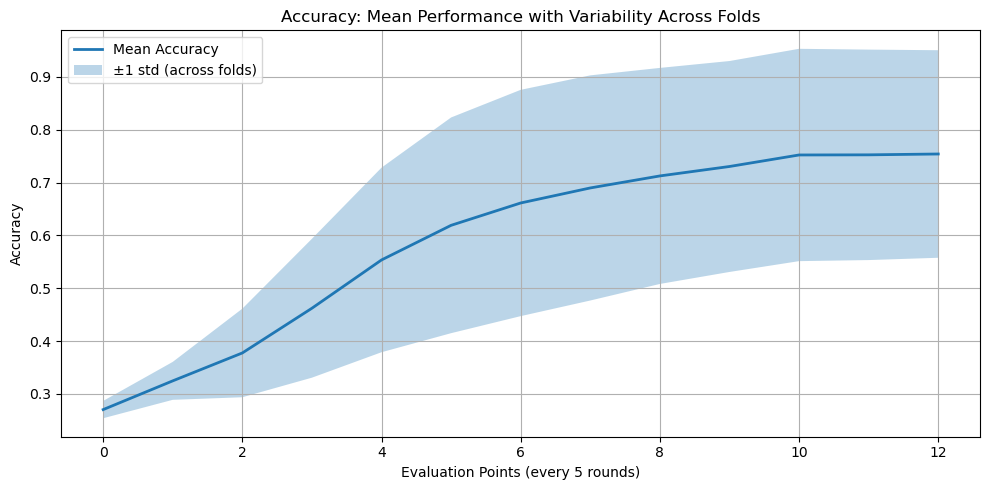

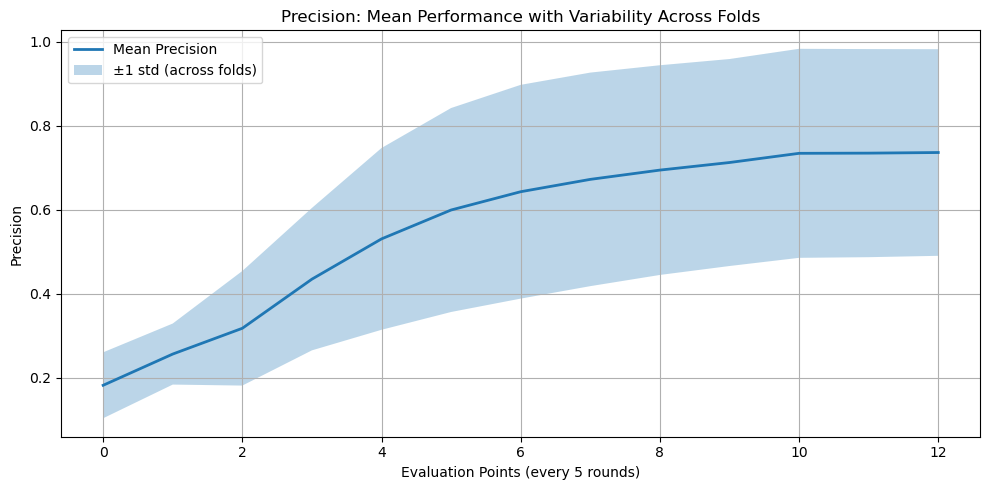

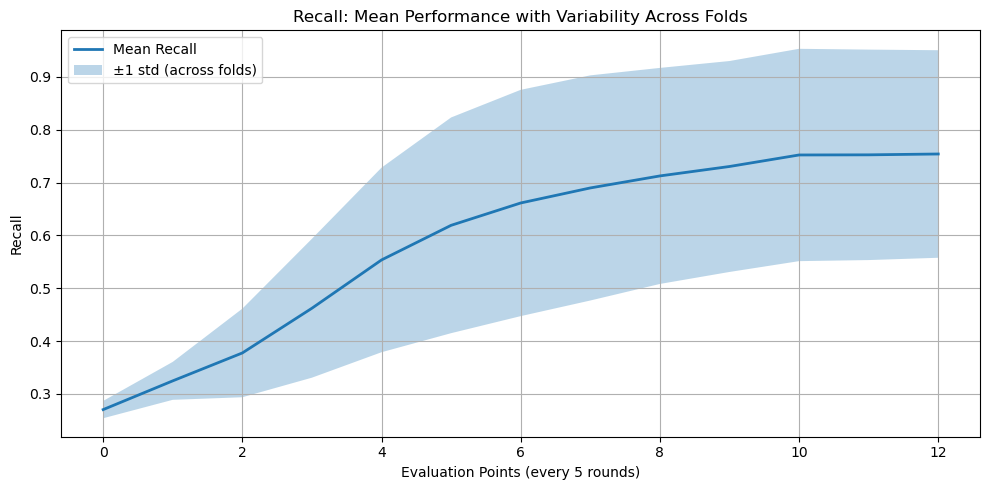

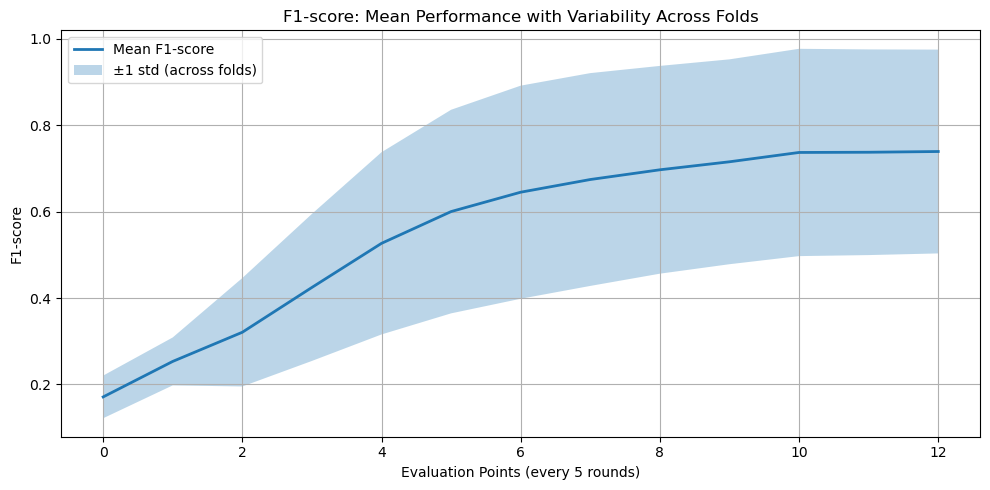

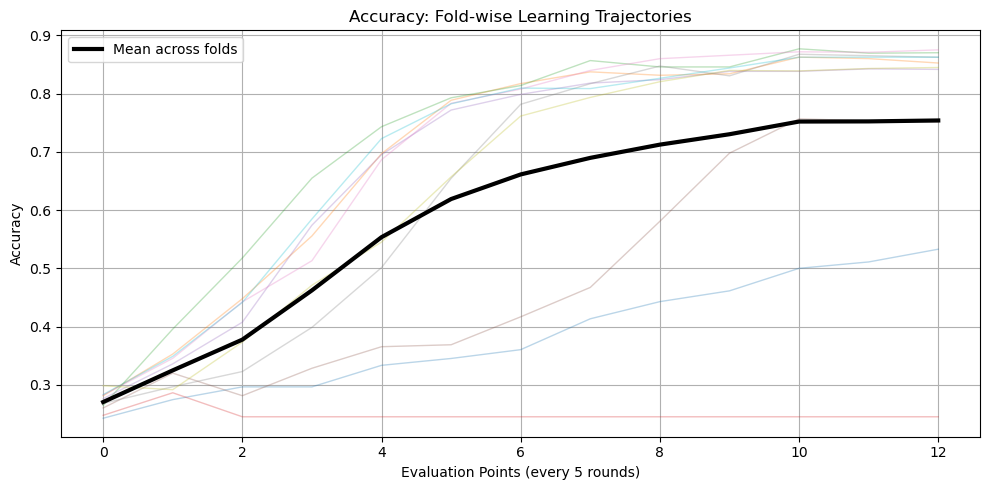

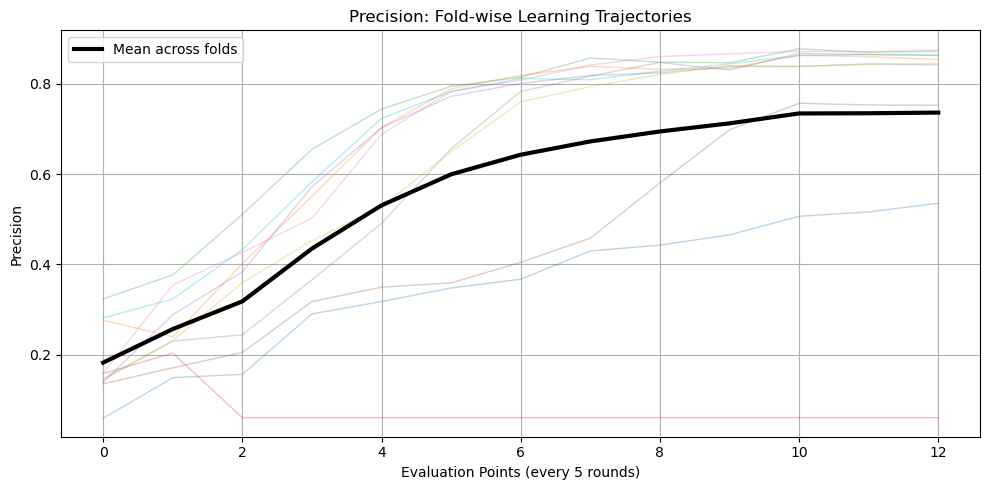

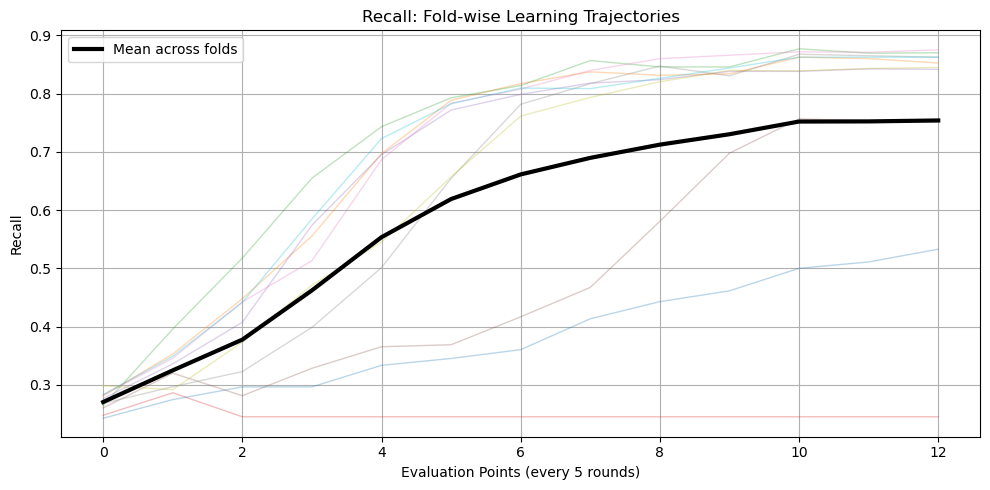

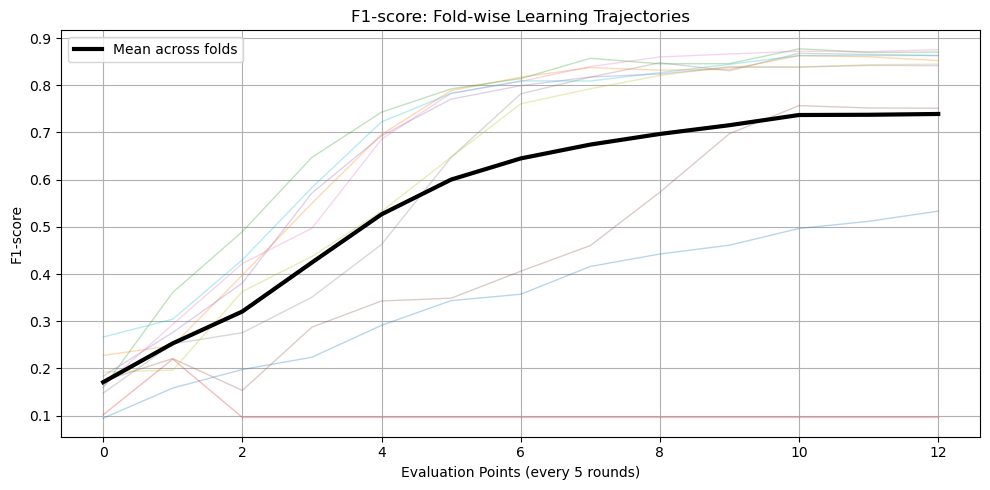

In [ ]:
print("Loading dataset...")
df = pd.read_csv(CSV_PATH)
print(f"Total samples: {len(df)}")
print(f"\nDirection counts:\n{df['direction'].value_counts()}")

# Map directions to labels
direction_map = {'forward': 0, 'backward': 1, 'left': 2, 'right': 3}
df['direction_label'] = df['direction'].map(direction_map)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Run optimized cross-validation
cv_results = run_cross_validation_optimized(
    df=df,
    k_folds=K_FOLDS,
    num_rounds=NUM_ROUNDS,
    num_clients=NUM_CLIENTS,
    local_epochs=LOCAL_EPOCHS
)

# Visualize results
print("\nGenerating plots...")
visualize_cv_results(cv_results)

In [ ]:
# Replace dataset label
# Make it 5 folds and 30 rounds
# Fix the rounds number on the plot (times by two)
# Change round_idx to round_idx+1 in train single fold optimized when collecting the fold metrics as even rounds being the target
# Separate visualization cell
# save plots as pdf with the code below
# Just save the dictionary plots as json
import json
# Open a file in write mode ('w') and save the dictionary as JSON
with open('cv_results.json', 'w') as json_file:
    json.dump(cv_results, json_file, indent=4)